In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('../data/training/df.csv')
print(df)

       Unnamed: 0 meta.lifeCycle meta.department meta.disease  \
0               0             자견              내과           기타   
1               1             성견              내과           기타   
2               2             성견              내과           기타   
3               3            노령견              내과           기타   
4               4             성견              내과           기타   
...           ...            ...             ...          ...   
19201       19201            노령견             피부과           기타   
19202       19202             성견             피부과           기타   
19203       19203            노령견             피부과           기타   
19204       19204             성견             피부과           기타   
19205       19205            노령견             피부과           기타   

                                          qa.instruction  \
0               너는 반려견 건강 전문가야. 반려견 보호자의 질문에 전문가로서 답변해줘.   
1        너는 반려견의 건강에 대해 해박한 지식을 가진 전문가야. 보호자의 궁금증을 해소해줘.   
2      너는 반려견의 건강 상태를 정확하게 평가할 수 있는 수의사

In [4]:
df = df.drop(labels='qa.instruction',axis=1) #instruction은 데이터 생성 llm의 프롬프트라 필요없다

In [5]:
print(df)

       Unnamed: 0 meta.lifeCycle meta.department meta.disease  \
0               0             자견              내과           기타   
1               1             성견              내과           기타   
2               2             성견              내과           기타   
3               3            노령견              내과           기타   
4               4             성견              내과           기타   
...           ...            ...             ...          ...   
19201       19201            노령견             피부과           기타   
19202       19202             성견             피부과           기타   
19203       19203            노령견             피부과           기타   
19204       19204             성견             피부과           기타   
19205       19205            노령견             피부과           기타   

                                                qa.input  \
0      저희 집에서 기르고 있는 것으로 강아지는 제 팔뚝 정도 되는 작은 크기의 반려견입니...   
1      저희 집에서 기르고 있는 진돗개가 최근 설사를 하는 증상을 보이고 있습니다. 특히 ...   
2      항문낭을 관리하지 않다가 몇일 전, 제가 앉아 있는 동안 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19206 entries, 0 to 19205
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       19206 non-null  int64 
 1   meta.lifeCycle   19206 non-null  object
 2   meta.department  19206 non-null  object
 3   meta.disease     19205 non-null  object
 4   qa.input         19206 non-null  object
 5   qa.output        19206 non-null  object
dtypes: int64(1), object(5)
memory usage: 900.4+ KB


In [7]:
print(df.shape)
print(df['meta.disease'].value_counts())

(19206, 6)
meta.disease
기타           14774
중성화수술          579
무릎뼈 탈구         517
중독             414
골절             364
심장사상충          352
자궁축농증          329
외이염            288
위장관폐색          228
아토피성 피부염       224
방광염            200
결막염            134
부신피질기능항진증      117
제3안검탈출증         96
방광결석            81
유루증             81
급성신부전           68
전방십자인대파열        67
녹내장             49
치은염             44
복막염             30
혈소판감소증          29
단두종증후군          22
추간판질환           20
유선종양            13
무릎뼈탈구           12
건성각결막염          10
치근단농양           10
췌장염              9
담낭정액낭종           9
만성신부전            8
피부사상균증           7
백내장              4
빈혈               2
항문낭염             2
저혈당              2
기관지염             2
흉수               2
폐렴               1
위장관출혈            1
식도이물             1
각막궤양             1
장내이물             1
고관절이형증           1
Name: count, dtype: int64


In [8]:
print(df['meta.lifeCycle'].value_counts())

meta.lifeCycle
성견     6468
자견     6378
노령견    6360
Name: count, dtype: int64


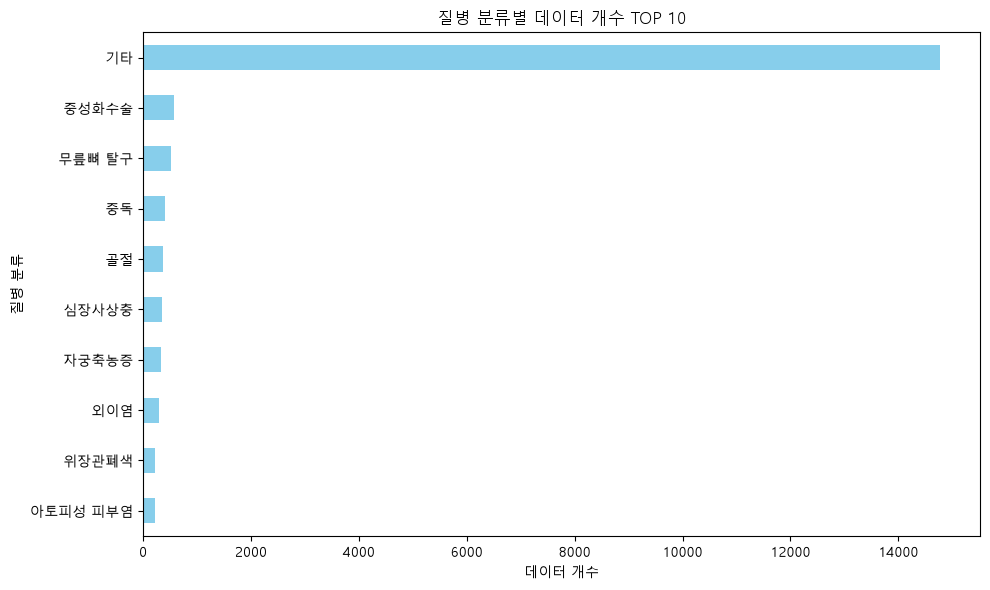

In [ ]:
#기타 포함 가로 막대그래프

import matplotlib.pyplot as plt

# 한글이 깨지지 않도록 설정(Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 질병별 데이터 개수
disease_counts = df['meta.disease'].value_counts()

# 개수가 많은 상위 10개
top10 = disease_counts.head(10).sort_values()

# 가로 막대그래프
plt.figure(figsize=(10, 6))
top10.plot(kind='barh', color='skyblue')

plt.title('질병 분류별 데이터 개수 TOP 10')
plt.xlabel('데이터 개수')
plt.ylabel('질병 분류')

plt.tight_layout()
plt.show()

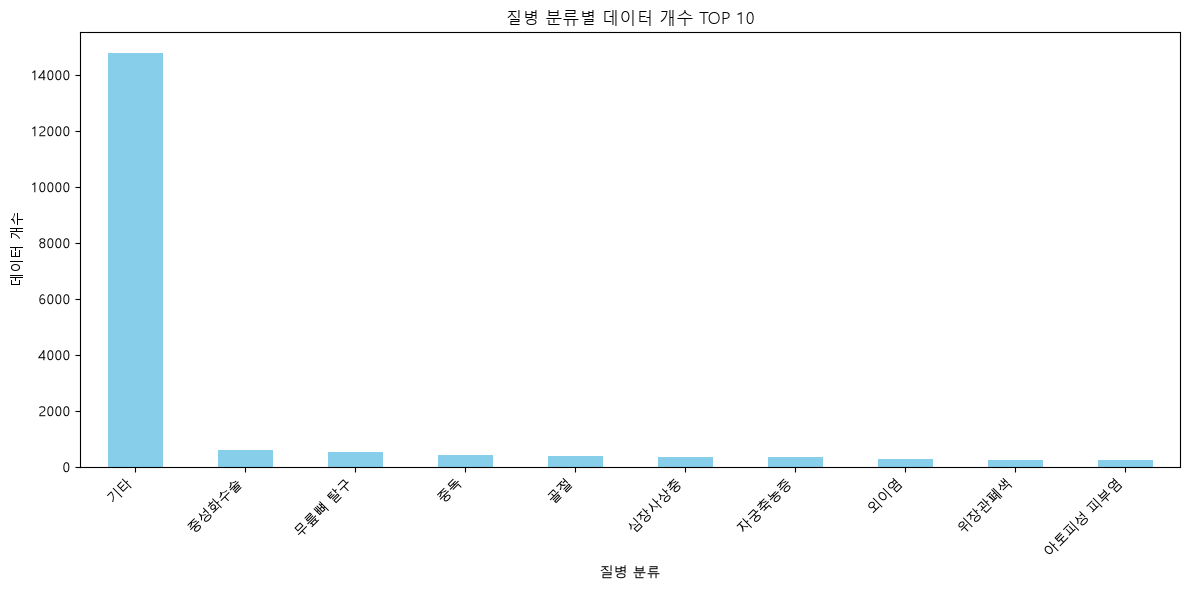

In [ ]:
# 기타 포함 세로 막대그래프

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 질병 데이터 개수 상위 10개
top10 = df['meta.disease'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top10.plot(kind='bar', color='skyblue')

plt.title('질병 분류별 데이터 개수 TOP 10')
plt.xlabel('질병 분류')
plt.ylabel('데이터 개수')

# 글자가 겹치지 않도록 기울이기
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

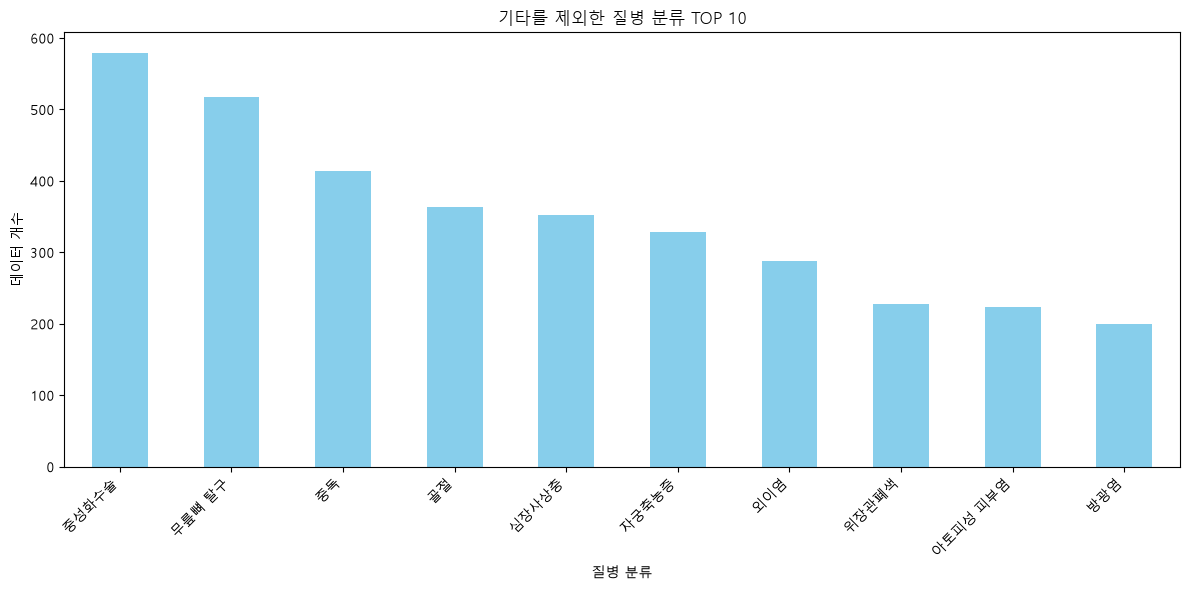

In [ ]:
# 기타 미포함 세로 막대그래프

import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# '기타'를 제외한 뒤 질병별 개수 계산
disease_counts = (
    df.loc[df['meta.disease'] != '기타', 'meta.disease']
    .value_counts()
    .head(10)
)

# 세로 막대그래프
plt.figure(figsize=(12, 6))

disease_counts.plot(
    kind='bar',
    color='skyblue'
)

plt.title('기타를 제외한 질병 분류 TOP 10')
plt.xlabel('질병 분류')
plt.ylabel('데이터 개수')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

말티즈            1905
푸들             1333
포메라니안 / 포메      927
비숑 / 비숑프리제      493
믹스견             474
시츄 / 시추         351
치와와             230
리트리버            192
진돗개             186
닥스훈트            147
요크셔테리어 / 요키     139
웰시코기            106
dtype: int64


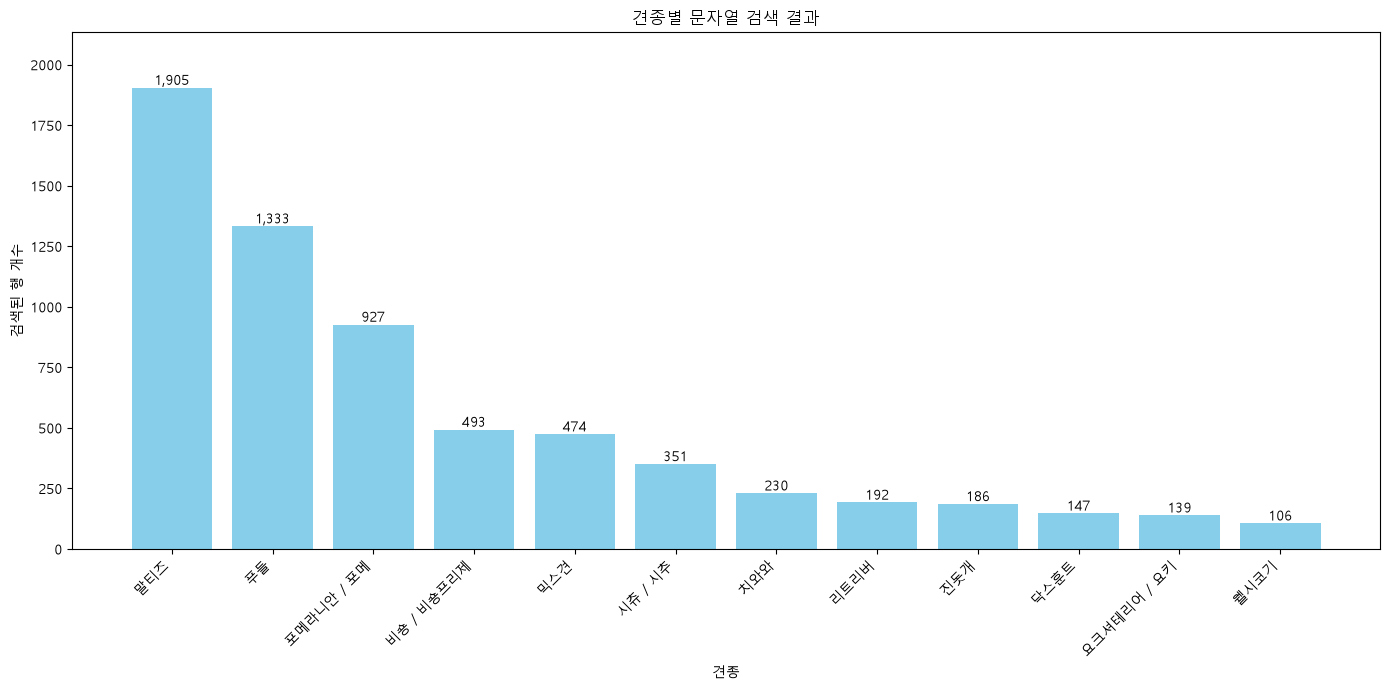

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 보고서 3.3절의 견종별 검색 문자열
breed_keywords = {
    '말티즈': ['말티즈'],
    '푸들': ['푸들'],
    '포메라니안 / 포메': ['포메'],
    '비숑 / 비숑프리제': ['비숑'],
    '믹스견': ['믹스견'],
    '시츄 / 시추': ['시츄'],
    '치와와': ['치와와'],
    '리트리버': ['리트리버'],
    '진돗개': ['진돗개'],
    '닥스훈트': ['닥스훈트'],
    '요크셔테리어 / 요키': ['요크셔테리어', '요키'],
    '웰시코기': ['코기']
}

# 결측값을 빈 문자열로 바꾼 후 검색
text = df['qa.input'].fillna('').astype(str)

breed_counts = {}

for breed, keywords in breed_keywords.items():
    # 모든 행을 처음에는 검색되지 않은 상태로 설정
    matched = pd.Series(False, index=df.index)

    # 별칭 중 하나라도 포함되어 있으면 True
    for keyword in keywords:
        matched |= text.str.contains(keyword, regex=False)

    breed_counts[breed] = int(matched.sum())

# 막대가 많은 순서대로 정렬
breed_counts = (
    pd.Series(breed_counts)
    .sort_values(ascending=False)
)

# 검색 결과 출력
print(breed_counts)

# 세로 막대그래프
plt.figure(figsize=(14, 7))

bars = plt.bar(
    breed_counts.index,
    breed_counts.values,
    color='skyblue'
)

plt.title('견종별 문자열 검색 결과')
plt.xlabel('견종')
plt.ylabel('검색된 행 개수')
plt.xticks(rotation=45, ha='right')

# 막대 위 숫자가 잘리지 않도록 여유 공간 추가
plt.ylim(0, breed_counts.max() * 1.12)

# 막대 위에 검색 건수 표시
for bar, count in zip(bars, breed_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count:,}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

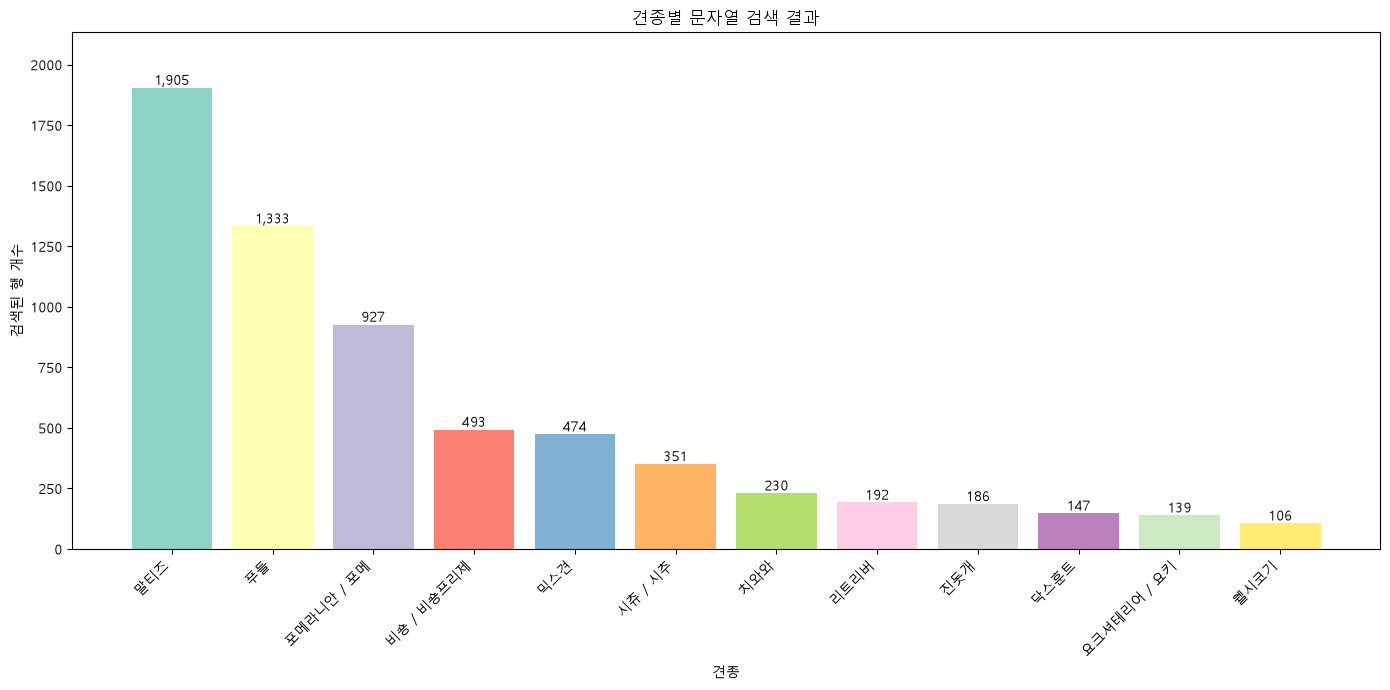

In [16]:
# 견종 개수만큼 서로 다른 색상 준비
colors = plt.get_cmap('Set3').colors[:len(breed_counts)]

# 세로 막대그래프
plt.figure(figsize=(14, 7))

bars = plt.bar(
    breed_counts.index,
    breed_counts.values,
    color=colors
)

plt.title('견종별 문자열 검색 결과')
plt.xlabel('견종')
plt.ylabel('검색된 행 개수')
plt.xticks(rotation=45, ha='right')

plt.ylim(0, breed_counts.max() * 1.12)

# 막대 위에 검색 건수 표시
for bar, count in zip(bars, breed_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count:,}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

['Unnamed: 0', 'meta.lifeCycle', 'meta.department', 'meta.disease', 'qa.instruction', 'qa.input', 'qa.output']
meta.department
내과     9846
외과     5107
피부과    2533
안과      970
치과      750
Name: count, dtype: Int64


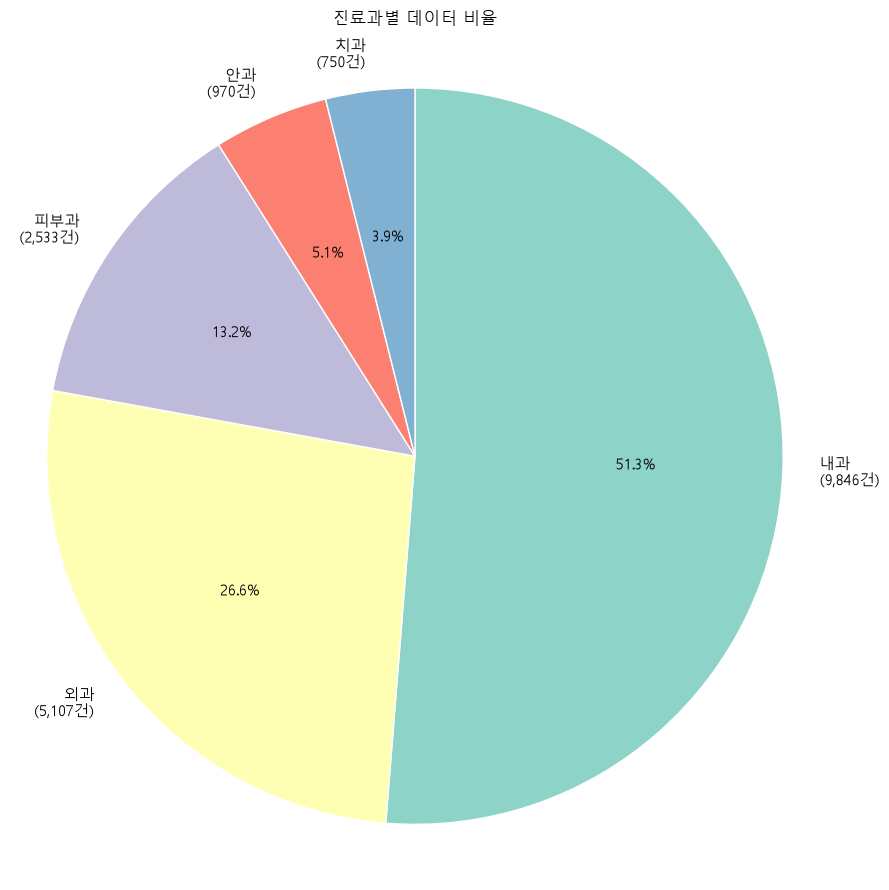

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Q&A 데이터 파일 경로
qa_file_path = Path(
    r"C:\Users\Playdata\Desktop\MLE-01-p1-team2-mytest\data\training\df.csv"
)

# 동물병원 데이터와 구분하기 위해 qa_df 사용
qa_df = pd.read_csv(
    qa_file_path,
    low_memory=False
)

# 컬럼 확인
print(qa_df.columns.tolist())

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 진료과별 개수 계산
department_counts = (
    qa_df['meta.department']
    .astype('string')
    .str.strip()
    .fillna('결측')
    .value_counts()
)

print(department_counts)

# 진료과별 색상
colors = plt.get_cmap('Set3').colors[:len(department_counts)]

# 진료과 이름과 데이터 개수를 함께 표시
labels = [
    f'{department}\n({count:,}건)'
    for department, count in department_counts.items()
]

# 파이그래프
plt.figure(figsize=(9, 9))

plt.pie(
    department_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1
    },
    textprops={
        'fontsize': 11
    }
)

plt.title('진료과별 데이터 비율')
plt.axis('equal')
plt.tight_layout()
plt.show()

meta.lifeCycle
성견     6468
자견     6378
노령견    6360
Name: count, dtype: Int64


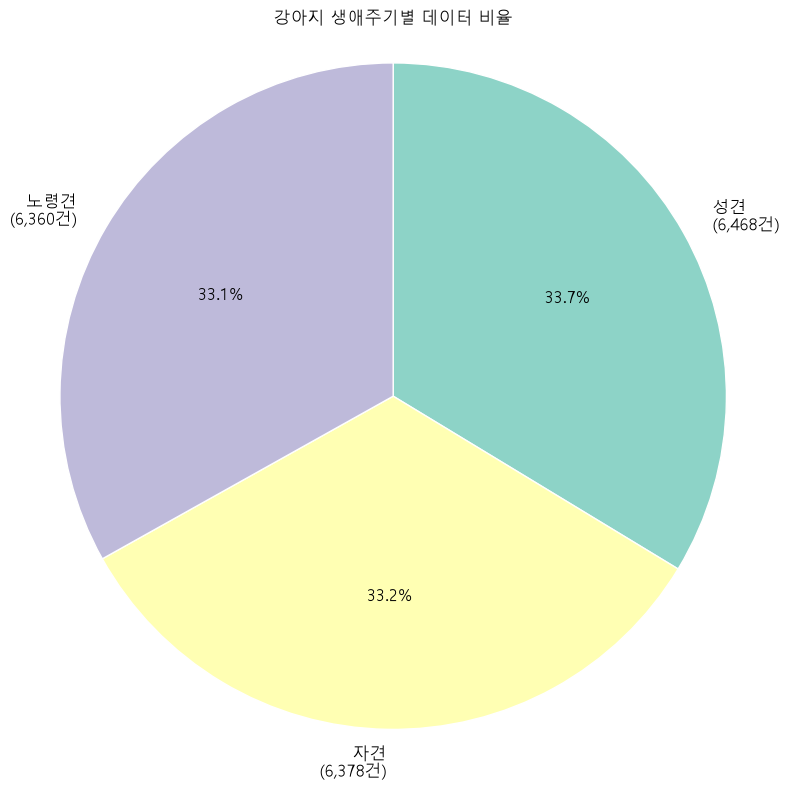

In [29]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Q&A 데이터 불러오기
qa_file_path = Path(
    r"C:\Users\Playdata\Desktop\MLE-01-p1-team2-mytest\data\training\df.csv"
)

qa_df = pd.read_csv(
    qa_file_path,
    low_memory=False
)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 생애주기별 개수 계산
life_cycle_counts = (
    qa_df['meta.lifeCycle']
    .astype('string')
    .str.strip()
    .fillna('결측')
    .value_counts()
)

print(life_cycle_counts)

# 각 생애주기에 다른 색상 적용
colors = plt.get_cmap('Set3').colors[:len(life_cycle_counts)]

# 이름과 데이터 개수를 함께 표시
labels = [
    f'{life_cycle}\n({count:,}건)'
    for life_cycle, count in life_cycle_counts.items()
]

# 파이그래프
plt.figure(figsize=(8, 8))

plt.pie(
    life_cycle_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1
    },
    textprops={
        'fontsize': 12
    }
)

plt.title('강아지 생애주기별 데이터 비율')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [35]:
import pandas as pd

file_path = r"C:\Users\Playdata\Desktop\MLE-01-p1-team2-mytest\동물_동물병원 (1).csv"

# 데이터 불러오기
hospital_df = pd.read_csv(
    file_path,
    encoding="utf-8-sig",
    low_memory=False
)

# 영업상태의 앞뒤 공백 제거
status = hospital_df["영업상태명"].astype("string").str.strip()

# '폐업'이 아닌 행만 남기기
active_hospital_df = hospital_df[
    status.ne("폐업").fillna(True)
].copy()

# 결과 확인
print("삭제 전:", len(hospital_df))
print("삭제된 폐업 데이터:", (status == "폐업").sum())
print("삭제 후:", len(active_hospital_df))
print(active_hospital_df["영업상태명"].value_counts())

# 새로운 CSV로 저장
output_path = r"C:\Users\Playdata\Desktop\MLE-01-p1-team2-mytest\동물_동물병원_폐업제외.csv"

active_hospital_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", output_path)

삭제 전: 10598
삭제된 폐업 데이터: 5050
삭제 후: 5548
영업상태명
영업/정상             5461
취소/말소/만료/정지/중지      59
휴업                  28
Name: count, dtype: int64
저장 완료: C:\Users\Playdata\Desktop\MLE-01-p1-team2-mytest\동물_동물병원_폐업제외.csv


In [36]:
import pandas as pd

file_path = r"C:\Users\Playdata\Desktop\MLE-01-p1-team2-mytest\동물_동물병원_폐업제외.csv"

raw_df = pd.read_csv(
    file_path,
    encoding="utf-8-sig",
    low_memory=False
)

analysis_df = raw_df.copy()

print("데이터 크기:", analysis_df.shape)
print("\n영업상태:")
print(analysis_df["영업상태명"].value_counts(dropna=False))

데이터 크기: (5548, 25)

영업상태:
영업상태명
영업/정상             5461
취소/말소/만료/정지/중지      59
휴업                  28
Name: count, dtype: int64


In [37]:
analysis_df["영업상태명"] = (
    analysis_df["영업상태명"]
    .astype("string")
    .str.strip()
)

analysis_df = analysis_df[
    analysis_df["영업상태명"] == "영업/정상"
].copy()

print("정상 영업 병원:", len(analysis_df))

정상 영업 병원: 5461


In [38]:
# NaN과 빈 문자열을 모두 결측치로 처리
blank_mask = (
    analysis_df.astype("string")
    .apply(lambda col: col.str.strip().eq(""))
    .fillna(False)
)

missing_mask = analysis_df.isna() | blank_mask

missing_summary = pd.DataFrame({
    "결측치_개수": missing_mask.sum(),
    "결측치_비율(%)": (
        missing_mask.mean() * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary["결측치_개수"] > 0
].sort_values("결측치_비율(%)", ascending=False)

display(missing_summary)

,결측치_개수,결측치_비율(%)
인허가취소일자,5461,100.0
폐업일자,5461,100.0
소재지우편번호,5461,100.0
재개업일자,5459,99.96
휴업시작일자,5446,99.73
휴업종료일자,5445,99.71
전화번호,2427,44.44
소재지면적,454,8.31
도로명우편번호,291,5.33
좌표정보(X),216,3.96


In [39]:
print("완전히 동일한 중복 행:", analysis_df.duplicated().sum())
print(
    "관리번호 중복:",
    analysis_df["관리번호"].duplicated().sum()
)

완전히 동일한 중복 행: 0
관리번호 중복: 0


In [40]:
numeric_columns = [
    "소재지면적",
    "좌표정보(X)",
    "좌표정보(Y)"
]

outlier_summary = []
flag_columns = []

for column in numeric_columns:
    values = pd.to_numeric(
        analysis_df[column],
        errors="coerce"
    )

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flag_column = f"{column}_IQR_이상치"

    analysis_df[flag_column] = (
        values.lt(lower) | values.gt(upper)
    )

    flag_columns.append(flag_column)

    outlier_summary.append({
        "컬럼": column,
        "하한값": lower,
        "상한값": upper,
        "이상치_개수": analysis_df[flag_column].sum()
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

,컬럼,하한값,상한값,이상치_개수
0,소재지면적,-168.000000,280.000000,388
1,좌표정보(X),34367.566616,454042.411610,1
2,좌표정보(Y),-29531.501683,729819.459228,3


In [41]:
any_outlier = analysis_df[flag_columns].any(axis=1)

outlier_rows = analysis_df.loc[
    any_outlier,
    [
        "관리번호",
        "사업장명",
        "소재지면적",
        "좌표정보(X)",
        "좌표정보(Y)",
        *flag_columns
    ]
]

print("이상치가 하나라도 있는 병원:", len(outlier_rows))

display(outlier_rows.head(20))

이상치가 하나라도 있는 병원: 392


,관리번호,사업장명,소재지면적,좌표정보(X),좌표정보(Y),소재지면적_IQR_이상치,좌표정보(X)_IQR_이상치,좌표정보(Y)_IQR_이상치
7,300000001020200001,선동물병원,326.50,197278.891939,453572.355621,True,False,False
36,301000001019920001,바우미우동물병원,306.00,201064.963697,450779.720971,True,False,False
38,302000001020050004,청화종합동물병원,284.00,199254.608613,447354.661581,True,False,False
73,303000001020120002,옥수수 동물병원,292.87,201538.056127,448894.755197,True,False,False
126,304000001020040003,건국대학교 부속 동물병원,1674.45,206445.881092,448922.881688,True,False,False
135,305000001019980001,뉴월드동물병원,348.00,205631.564598,451925.907664,True,False,False
161,305000001020230001,서울동물복지지원센터 동대문 동물병원,552.09,202523.469147,453317.110098,True,False,False
171,306000001020170001,로얄동물암치료센터,413.84,207017.815270,453914.639781,True,False,False
176,306000001020230001,로얄동물메디컬센터 본원,455.22,207017.815270,453914.639781,True,False,False
177,306000001020230002,로얄동물외과수술센터,602.02,207017.815270,453914.639781,True,False,False


In [45]:
import pandas as pd

input_path = r"C:\Users\Playdata\Desktop\MLE-01-p1-team2-mytest\동물_동물병원_폐업제외.csv"
output_path = r"C:\Users\Playdata\Desktop\MLE-01-p1-team2-mytest\동물_동물병원_최종.csv"

df = pd.read_csv(
    input_path,
    encoding="utf-8-sig",
    low_memory=False
)

# 전화번호를 제외한 열만 선택
selected_columns = [
    "영업상태명",
    "사업장명",
    "도로명주소"
]

result_df = df[selected_columns].copy()

result_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("데이터 크기:", result_df.shape)
print("저장 위치:", output_path)

display(result_df.head())

데이터 크기: (5548, 3)
저장 위치: C:\Users\Playdata\Desktop\MLE-01-p1-team2-mytest\동물_동물병원_최종.csv


,영업상태명,사업장명,도로명주소
0,휴업,효자동물병원,서울특별시 종로구 자하문로 66-2 (효자동)
1,휴업,효자동물병원,서울특별시 종로구 자하문로 66-2 (효자동)
2,휴업,효자동물병원,서울특별시 종로구 자하문로 66-2 (효자동)
3,취소/말소/만료/정지/중지,효자동물병원,서울특별시 종로구 자하문로 66-2 (효자동)
4,취소/말소/만료/정지/중지,월드펫동물병원,서울특별시 종로구 진흥로 473 (신영동)


In [46]:
import pandas as pd

input_path = r"C:\Users\Playdata\Desktop\MLE-01-p1-team2-mytest\동물_동물병원_최종.csv"

output_path = r"C:\Users\Playdata\Desktop\MLE-01-p1-team2-mytest\동물_동물병원_최종_중복제거.csv"

# 데이터 불러오기
df = pd.read_csv(
    input_path,
    encoding="utf-8-sig",
    low_memory=False
)

# 공백을 모두 제거한 비교용 컬럼 생성
df["_사업장명_비교용"] = (
    df["사업장명"]
    .astype("string")
    .str.replace(r"\s+", "", regex=True)
)

df["_도로명주소_비교용"] = (
    df["도로명주소"]
    .astype("string")
    .str.replace(r"\s+", "", regex=True)
)

# 두 컬럼이 모두 같은 중복 행 확인
duplicate_mask = df.duplicated(
    subset=[
        "_사업장명_비교용",
        "_도로명주소_비교용"
    ],
    keep="first"
)

print("제거 전 행 개수:", len(df))
print("중복으로 제거할 행 개수:", duplicate_mask.sum())

# 첫 번째 행만 남기고 중복 제거
result_df = (
    df.loc[~duplicate_mask]
    .drop(
        columns=[
            "_사업장명_비교용",
            "_도로명주소_비교용"
        ]
    )
    .reset_index(drop=True)
)

print("제거 후 행 개수:", len(result_df))

# 새로운 파일로 저장
result_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", output_path)
display(result_df.head())

제거 전 행 개수: 5548
중복으로 제거할 행 개수: 10
제거 후 행 개수: 5538
저장 완료: C:\Users\Playdata\Desktop\MLE-01-p1-team2-mytest\동물_동물병원_최종_중복제거.csv


,영업상태명,사업장명,도로명주소
0,휴업,효자동물병원,서울특별시 종로구 자하문로 66-2 (효자동)
1,취소/말소/만료/정지/중지,월드펫동물병원,서울특별시 종로구 진흥로 473 (신영동)
2,영업/정상,광화문동물병원,"서울특별시 종로구 자하문로 35-3, 씨에스코즈빌 101호 (통인동)"
3,영업/정상,경희궁 바른 동물병원,"서울특별시 종로구 송월길 99, 상가동 2층 2229호 (홍파동, 경희궁자이 2단지)"
4,영업/정상,선동물병원,"서울특별시 종로구 자하문로 95, 신교빌딩 1층 (신교동)"
